In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split
import tifffile as tiff
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from PIL import Image

# Custom Dataset Loader for Unlabeled TIFF Images
class UnlabeledTIFFDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = [os.path.join(root_dir, fname) for fname in os.listdir(root_dir) if fname.lower().endswith(('tif', 'tiff'))]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            image = tiff.imread(img_path).astype(np.float32)   
            image = image * 240
            image[image > 254] = 254
            if image.ndim == 3:
                image = image[0]
            
        except Exception as e:
            print(f"Warning: Skipping unreadable image {img_path} - {e}")
            return self.__getitem__((idx + 1) % len(self.image_paths))

        image = image/255

        if self.transform:
            image = self.transform(image)

        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)
        image = image.squeeze(1)
        return image, 0

# Step 1: Define a standard Autoencoder (AE)
import torch
import numpy as np
from tqdm import tqdm
from torchvision import transforms
from skimage import io
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE


class AE(torch.nn.Module):
    def __init__(self, latent_dim=8):
        super(AE, self).__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Conv2d(1, 32, 3, stride=2, padding=1),  # 32 -> 16
            torch.nn.LeakyReLU(0.01),
            torch.nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 16 -> 8
            torch.nn.LeakyReLU(0.01),
            torch.nn.Conv2d(64, 128, 3, stride=2, padding=1),  # 8 -> 4
            torch.nn.LeakyReLU(0.01),
            torch.nn.Flatten()
        )
        self.encoder_fc = torch.nn.Sequential(
            torch.nn.Linear(128 * 4 * 4, 1024),
            torch.nn.LeakyReLU(0.01),
            torch.nn.Linear(1024, latent_dim)
        )

        self.decoder_fc = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, 1024),
            torch.nn.LeakyReLU(0.01),
            torch.nn.Linear(1024, 128 * 4 * 4)
        )

        self.decoder = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),  # 4 -> 8
            torch.nn.LeakyReLU(0.01),
            torch.nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),  # 8 -> 16
            torch.nn.LeakyReLU(0.01),
            torch.nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),   # 16 -> 32
            torch.nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        return self.encoder_fc(x)

    def decode(self, z):
        x = self.decoder_fc(z).view(-1, 128, 4, 4)
        return self.decoder(x)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z

def plot_reconstruction_progress(model, dataloader, device, epoch):
    """Plot original vs reconstructed images during training"""
    model.eval()
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            recon, _ = model(x)
            break  # only one batch

    x = x.cpu()
    recon = recon.cpu()

    print(f"Input stats — min: {x.min().item():.4f}, max: {x.max().item():.4f}, mean: {x.mean().item():.4f}, std: {x.std().item():.4f}")
    print(f"Reconstruction stats — min: {recon.min().item():.4f}, max: {recon.max().item():.4f}, mean: {recon.mean().item():.4f}, std: {recon.std().item():.4f}")

    n = min(8, x.size(0))
    fig, axes = plt.subplots(2, n, figsize=(n * 1, 2))
    for i in range(n):
        axes[0, i].imshow(x[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[0, i].axis("off")
        axes[1, i].imshow(recon[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[1, i].axis("off")
    plt.suptitle(f"Reconstruction at Epoch {epoch}")
    plt.tight_layout()
    plt.show()



# Step 2: Train Autoencoder and Extract Latent Representations
def train_ae(model, train_loader, val_loader, epochs=1000, lr=1e-4):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for x, _ in train_loader:
            x = x.to(device)
            recon, _ = model(x)
            loss = loss_fn(recon, x)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                recon, _ = model(x)
                loss = loss_fn(recon, x)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        if (epoch + 1) % 100 == 0:
            plot_reconstruction_progress(model, val_loader, device, epoch + 1)
            

    # Plot training and validation loss
    plt.plot(range(epochs), train_losses, label='Train Loss')
    plt.plot(range(epochs), val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training vs Validation Loss')
    plt.show()

    return model


# Load Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from torch.utils.data import ConcatDataset

dir1 = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_pslocation00/tiff_patches32_65p_20250909_1521'
dir2 = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/y_ch1_major/y_ch1_patches_gridonly_pslocation00/tiff_patches32_65p_20250909_1532'

transform = transforms.Compose([transforms.ToTensor()])

ds1 = UnlabeledTIFFDataset(root_dir=dir1, transform=transform)
ds2 = UnlabeledTIFFDataset(root_dir=dir2, transform=transform)



dataset = ConcatDataset([ds1, ds2])


# Split dataset into training and validation sets
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)




In [2]:
len(dataset)

6586

/tmp/ipykernel_1611804/4235926560.py:42: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)


Epoch 20/1000, Train Loss: 0.0111, Val Loss: 0.0115
Epoch 40/1000, Train Loss: 0.0102, Val Loss: 0.0111
Epoch 60/1000, Train Loss: 0.0098, Val Loss: 0.0110
Epoch 80/1000, Train Loss: 0.0094, Val Loss: 0.0110
Epoch 100/1000, Train Loss: 0.0089, Val Loss: 0.0112
Input stats — min: 0.0000, max: 0.9486, mean: 0.1253, std: 0.1511
Reconstruction stats — min: 0.0084, max: 0.9935, mean: 0.1237, std: 0.1157


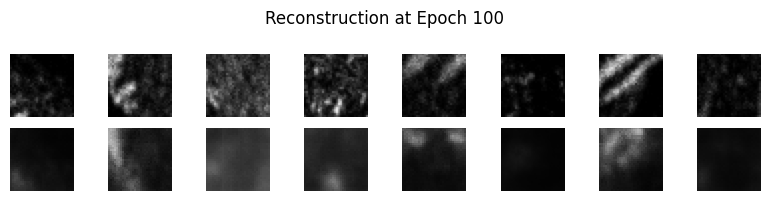

Epoch 120/1000, Train Loss: 0.0085, Val Loss: 0.0113
Epoch 140/1000, Train Loss: 0.0082, Val Loss: 0.0116
Epoch 160/1000, Train Loss: 0.0078, Val Loss: 0.0118
Epoch 180/1000, Train Loss: 0.0075, Val Loss: 0.0121
Epoch 200/1000, Train Loss: 0.0073, Val Loss: 0.0123
Input stats — min: 0.0000, max: 0.9486, mean: 0.1253, std: 0.1511
Reconstruction stats — min: 0.0050, max: 0.9988, mean: 0.1251, std: 0.1207


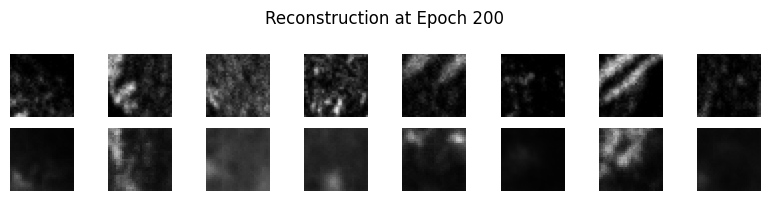

Epoch 220/1000, Train Loss: 0.0070, Val Loss: 0.0125
Epoch 240/1000, Train Loss: 0.0068, Val Loss: 0.0127
Epoch 260/1000, Train Loss: 0.0066, Val Loss: 0.0129
Epoch 280/1000, Train Loss: 0.0064, Val Loss: 0.0131
Epoch 300/1000, Train Loss: 0.0063, Val Loss: 0.0132
Input stats — min: 0.0000, max: 0.9486, mean: 0.1253, std: 0.1511
Reconstruction stats — min: 0.0035, max: 0.9994, mean: 0.1239, std: 0.1231


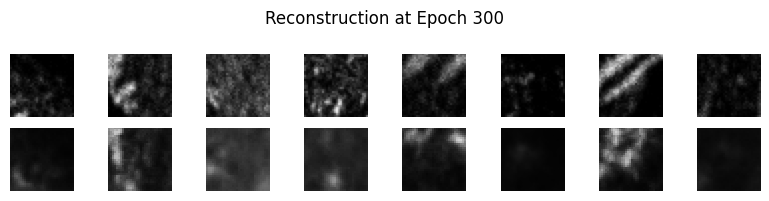

Epoch 320/1000, Train Loss: 0.0062, Val Loss: 0.0134
Epoch 340/1000, Train Loss: 0.0060, Val Loss: 0.0136
Epoch 360/1000, Train Loss: 0.0059, Val Loss: 0.0136
Epoch 380/1000, Train Loss: 0.0058, Val Loss: 0.0138
Epoch 400/1000, Train Loss: 0.0057, Val Loss: 0.0139
Input stats — min: 0.0000, max: 0.9486, mean: 0.1253, std: 0.1511
Reconstruction stats — min: 0.0031, max: 0.9972, mean: 0.1227, std: 0.1241


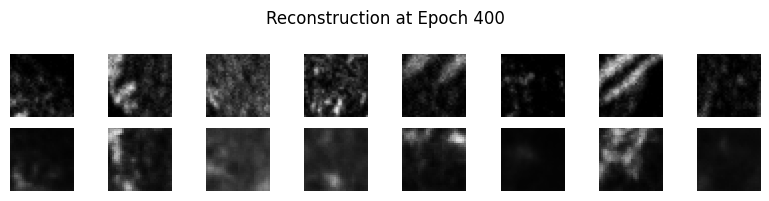

Epoch 420/1000, Train Loss: 0.0056, Val Loss: 0.0139
Epoch 440/1000, Train Loss: 0.0054, Val Loss: 0.0141
Epoch 460/1000, Train Loss: 0.0053, Val Loss: 0.0141
Epoch 480/1000, Train Loss: 0.0052, Val Loss: 0.0142
Epoch 500/1000, Train Loss: 0.0052, Val Loss: 0.0144
Input stats — min: 0.0000, max: 0.9486, mean: 0.1253, std: 0.1511
Reconstruction stats — min: 0.0027, max: 0.9975, mean: 0.1220, std: 0.1280


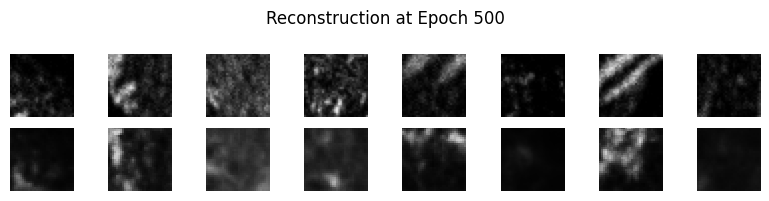

Epoch 520/1000, Train Loss: 0.0051, Val Loss: 0.0145
Epoch 540/1000, Train Loss: 0.0050, Val Loss: 0.0146
Epoch 560/1000, Train Loss: 0.0050, Val Loss: 0.0146
Epoch 580/1000, Train Loss: 0.0049, Val Loss: 0.0147
Epoch 600/1000, Train Loss: 0.0048, Val Loss: 0.0147
Input stats — min: 0.0000, max: 0.9486, mean: 0.1253, std: 0.1511
Reconstruction stats — min: 0.0035, max: 0.9949, mean: 0.1221, std: 0.1294


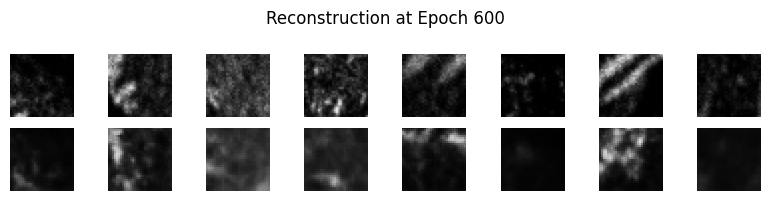

Epoch 620/1000, Train Loss: 0.0047, Val Loss: 0.0149
Epoch 640/1000, Train Loss: 0.0047, Val Loss: 0.0150
Epoch 660/1000, Train Loss: 0.0046, Val Loss: 0.0149
Epoch 680/1000, Train Loss: 0.0045, Val Loss: 0.0150
Epoch 700/1000, Train Loss: 0.0045, Val Loss: 0.0151
Input stats — min: 0.0000, max: 0.9486, mean: 0.1253, std: 0.1511
Reconstruction stats — min: 0.0038, max: 0.9938, mean: 0.1265, std: 0.1321


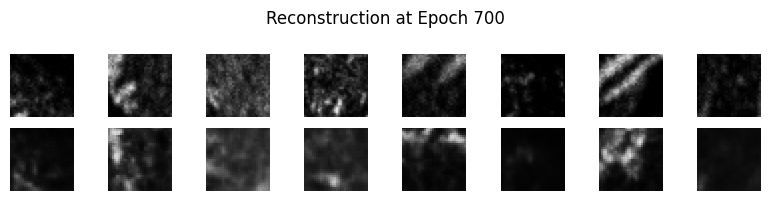

Epoch 720/1000, Train Loss: 0.0045, Val Loss: 0.0154
Epoch 740/1000, Train Loss: 0.0044, Val Loss: 0.0152
Epoch 760/1000, Train Loss: 0.0044, Val Loss: 0.0152
Epoch 780/1000, Train Loss: 0.0043, Val Loss: 0.0152
Epoch 800/1000, Train Loss: 0.0043, Val Loss: 0.0153
Input stats — min: 0.0000, max: 0.9486, mean: 0.1253, std: 0.1511
Reconstruction stats — min: 0.0027, max: 0.9961, mean: 0.1227, std: 0.1322


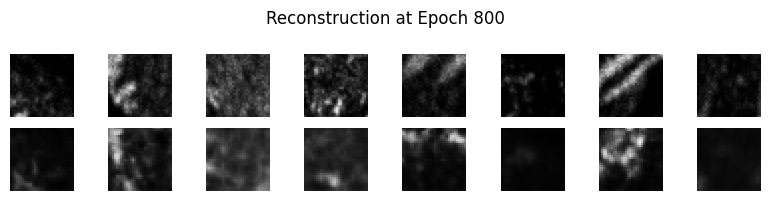

Epoch 820/1000, Train Loss: 0.0043, Val Loss: 0.0153
Epoch 840/1000, Train Loss: 0.0042, Val Loss: 0.0155
Epoch 860/1000, Train Loss: 0.0041, Val Loss: 0.0155
Epoch 880/1000, Train Loss: 0.0041, Val Loss: 0.0154
Epoch 900/1000, Train Loss: 0.0040, Val Loss: 0.0156
Input stats — min: 0.0000, max: 0.9486, mean: 0.1253, std: 0.1511
Reconstruction stats — min: 0.0016, max: 0.9939, mean: 0.1239, std: 0.1348


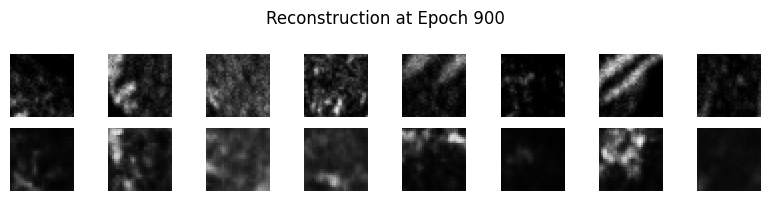

Epoch 920/1000, Train Loss: 0.0040, Val Loss: 0.0156
Epoch 940/1000, Train Loss: 0.0040, Val Loss: 0.0158
Epoch 960/1000, Train Loss: 0.0039, Val Loss: 0.0156
Epoch 980/1000, Train Loss: 0.0039, Val Loss: 0.0161
Epoch 1000/1000, Train Loss: 0.0038, Val Loss: 0.0158
Input stats — min: 0.0000, max: 0.9486, mean: 0.1253, std: 0.1511
Reconstruction stats — min: 0.0016, max: 0.9903, mean: 0.1243, std: 0.1346


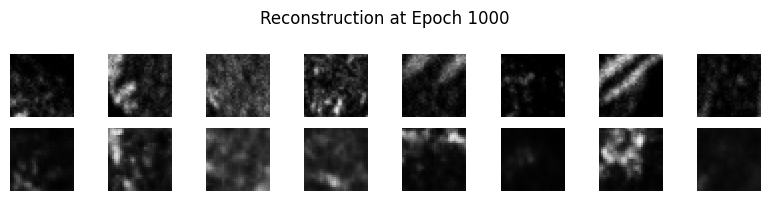

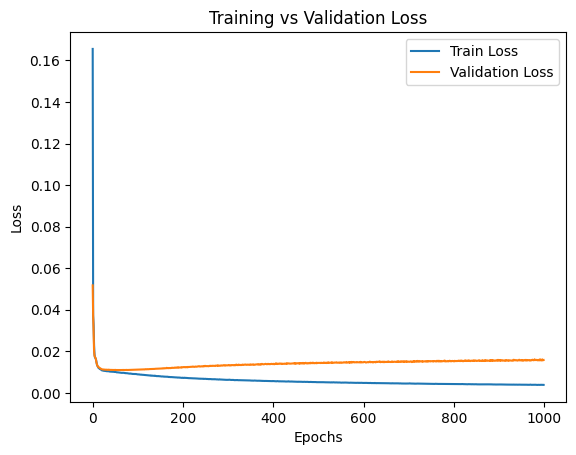

In [3]:
# Train AE
ae = AE().to(device)
ae = train_ae(ae, train_loader, val_loader)

torch.save(ae, 'pax_ch1_ps32_ctrl_Y_grid_00_bestmodel_1000epoch.pt')

In [4]:
len(ds1)

4205

In [5]:
len(ds2)


2381

In [6]:
import torch
import numpy as np
from tqdm import tqdm
from torchvision import transforms
from skimage import io
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from umap import UMAP
import joblib

# Step 3: Cluster in Latent Space

def cluster_latents(model, dataloader, num_clusters=6):
    model.eval()
    latents = []
    images = []
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            _, z = model(x)
            latents.append(z.cpu().numpy())
            images.append(x.cpu())
    latents = np.concatenate(latents, axis=0)
    images = torch.cat(images, dim=0)

    kmeans = KMeans(n_clusters=num_clusters, random_state=0).fit(latents)
    labels = kmeans.labels_

    # Save the model
    joblib.dump(kmeans, "kmeans_model_pax_ch1_ps32_ctrl_Y_grid_00_1000epoch.pkl")
    return latents, labels, images

# Step 4: Visualize Clusters with t-SNE and Reconstructed Images

def visualize_clusters(latents, labels, images, model):


    umap = UMAP(n_components=2, random_state=42)
    latents_2d = umap.fit_transform(latents)

    # Save model
    joblib.dump(umap, "umap_model_pax_ch1_ps32_ctrl_Y_grid_00_1000epoch.pkl")

    plt.figure(figsize=(5, 3.5))
    plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels, cmap='tab10', alpha=0.7, s=1)
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title("2D Visualization of Latent Space using UMAP")
    plt.show()

    selected_images = []
    selected_labels = set()
    for i, label in enumerate(labels):
        if label not in selected_labels:
            selected_labels.add(label)
            selected_images.append(images[i])
        if len(selected_labels) == 4:
            break

    selected_images = torch.stack(selected_images).to(device)
    reconstructed, _ = model(selected_images)

    fig, axes = plt.subplots(2, len(selected_images), figsize=(15, 5))
    for i in range(len(selected_images)):
        axes[0, i].imshow(selected_images[i].squeeze().cpu(), cmap='gray', vmax=1.0, vmin=0)
        axes[1, i].imshow(reconstructed[i].squeeze().cpu().detach(), cmap='gray', vmax=1.0, vmin=0)
        axes[0, i].axis('off')
        axes[1, i].axis('off')
    plt.show()
    return latents_2d


In [7]:
import torch
import numpy as np
from tqdm import tqdm
from torchvision import transforms
from skimage import io
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE


# Step 5: Show multiple decoded images per cluster

def cluster_and_display_images(latents, labels, images, model, num_samples_per_cluster=10):
    unique_labels = np.unique(labels)
    fig, axes = plt.subplots(len(unique_labels)*2, num_samples_per_cluster, figsize=(num_samples_per_cluster*1.5, len(unique_labels)*2))

    for cluster_idx, cluster_label in enumerate(unique_labels):
        cluster_indices = np.where(labels == cluster_label)[0][:num_samples_per_cluster]
        cluster_images = images[cluster_indices].to(device)
        recon_images, _ = model(cluster_images)

        for i in range(num_samples_per_cluster):
            axes[2 * cluster_idx, i].imshow(cluster_images[i].squeeze().cpu(), cmap='gray', vmin=0, vmax=1.0)
            axes[2 * cluster_idx + 1, i].imshow(recon_images[i].squeeze().cpu().detach(), cmap='gray', vmin=0, vmax=1.0)
            axes[2 * cluster_idx, i].axis('off')
            axes[2 * cluster_idx + 1, i].axis('off')

    plt.tight_layout()
    plt.show()


In [8]:
def cluster_2Dplot(latents, ind1,ind2,labels):
    plt.figure(figsize=(8, 6))
    plt.scatter(latents[:, ind1], latents[:, ind2], c=labels, cmap='tab10', alpha=0.7, s=1)
    plt.xlabel("F1")
    plt.ylabel("F2")
    plt.title("2D Visualization of Latent Space F0-F1")
    plt.show()
    

In [9]:
def cluster_3Dplot(latents, ind1,ind2,ind3, labels):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(latents[:, ind1], latents[:, ind2],latents[:, ind3], c=labels, cmap='tab10',s=1)
    plt.xlabel('F'+str(ind1))
    plt.ylabel('F'+str(ind2))
    plt.ylabel('F'+str(ind3))
    plt.title('3D Visualization of Latent Space F' +str(ind1)+'-'+str(ind2)+'-'+str(ind3))
    plt.show()
    

In [10]:
latents, labels, images = cluster_latents(ae, train_loader, num_clusters=6)


/tmp/ipykernel_1611804/4235926560.py:42: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)


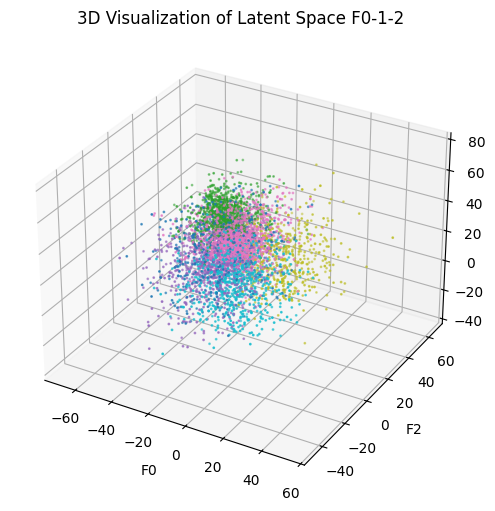

In [11]:
cluster_3Dplot(latents, 0,1,2,labels)

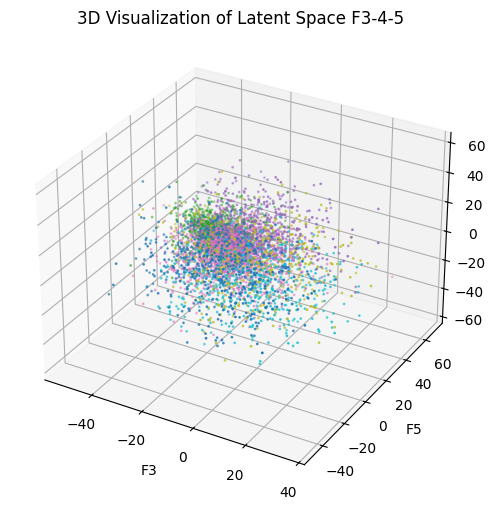

In [12]:
cluster_3Dplot(latents, 3,4,5,labels)

In [13]:
images.shape

torch.Size([5268, 1, 32, 32])

In [14]:
pax_ctrl_loader = DataLoader(ds1, batch_size=128, shuffle=False)
pax_y_loader = DataLoader(ds2, batch_size=128, shuffle=False)

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


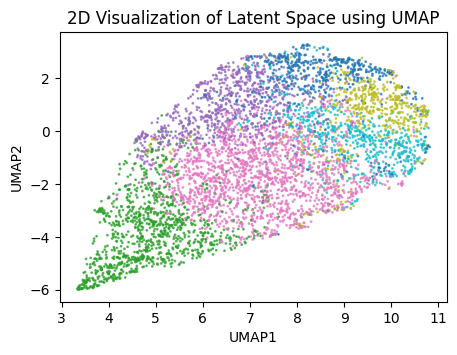

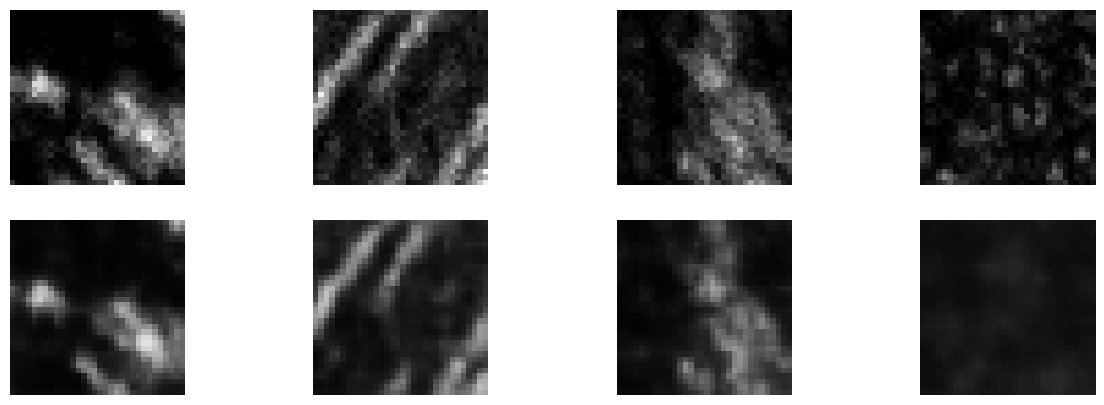

In [15]:
latents_2d = visualize_clusters(latents, labels, images, ae)


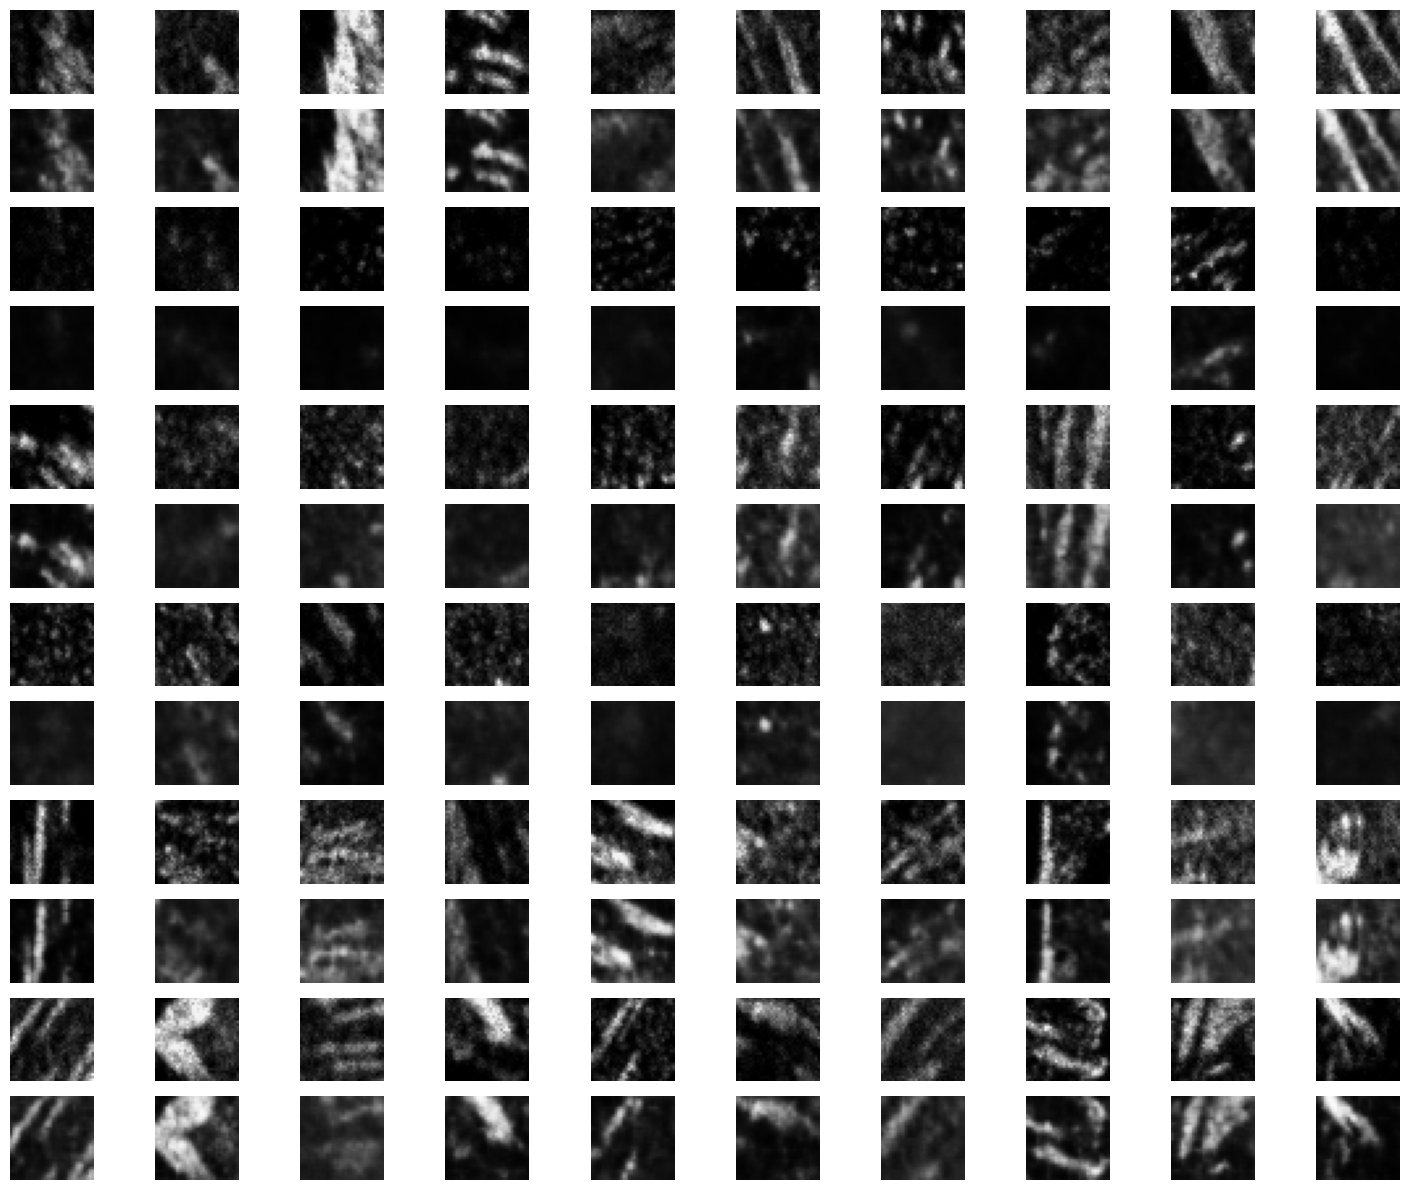

In [16]:
cluster_and_display_images(latents, labels, images, ae, num_samples_per_cluster=10)
